## Imports

In [41]:
import sys
print(sys.executable)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


d:\Tisya\projects\AYUSH\venv\Scripts\python.exe


## Load the data

In [42]:
train = pd.read_csv(
    "../data/processed/FD001/train_FD001_with_rul.csv"
)

print("Shape:", train.shape)
display(train.head())


Shape: (20631, 20)


,unit,cycle,op_setting_1,op_setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


## Features and Target

In [43]:
target = "RUL"

features = [
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_17",
    "sensor_20",
    "sensor_21"
]

X = train[features].copy()
y = train[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (20631, 18)
y shape: (20631,)


## Engine Split

In [44]:
units = train["unit"].unique()

train_units, val_units = train_test_split(
    units,
    test_size=0.20,
    random_state=42
)

train_mask = train["unit"].isin(train_units)
val_mask = train["unit"].isin(val_units)

X_train = train.loc[train_mask, features].copy()
y_train = train.loc[train_mask, target].copy()

X_val = train.loc[val_mask, features].copy()
y_val = train.loc[val_mask, target].copy()

print("Training engines:", len(train_units))
print("Validation engines:", len(val_units))

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

Training engines: 80
Validation engines: 20
X_train: (16561, 18)
y_train: (16561,)
X_val: (4070, 18)
y_val: (4070,)


## Trainaing Linear Regression

In [45]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_val)


mae = mean_absolute_error(y_val, y_pred)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))

r2 = r2_score(y_val, y_pred)

print("Linear Regression Results")
print(f"MAE :  {mae:.3f}")
print(f"RMSE:  {rmse:.3f}")
print(f"R²  :  {r2:.3f}")

Linear Regression Results
MAE :  25.155
RMSE:  31.656
R²  :  0.768


### visualise

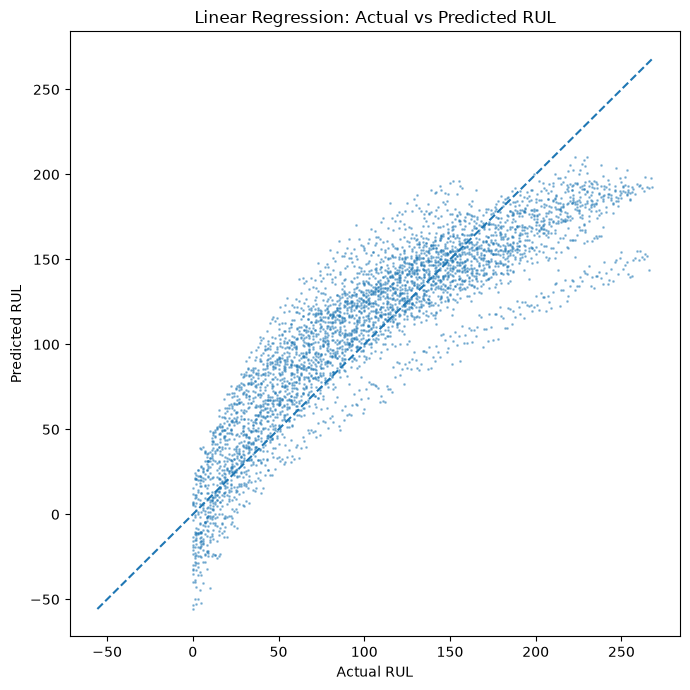

In [46]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_val,
    y_pred,
    alpha=0.4,
    s=1
)

min_value = min(y_val.min(), y_pred.min())
max_value = max(y_val.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Linear Regression: Actual vs Predicted RUL")

plt.tight_layout()
plt.savefig('../reports/FD001/figures/Linear_Regression_Actual_vs_Predicted_RUL.png', dpi=300, bbox_inches='tight')
plt.show()

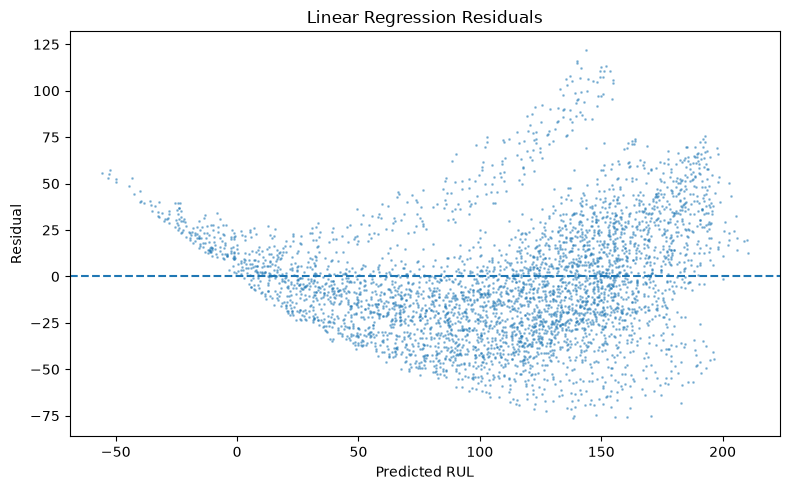

In [47]:
residuals = y_val - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.4,
    s=1
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted RUL")
plt.ylabel("Residual")
plt.title("Linear Regression Residuals")

plt.savefig('../reports/FD001/figures/Linear_Regression_Residuals.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [48]:
all_baseline_results = pd.DataFrame({
    "model": ["Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2]
})

display(all_baseline_results)


all_baseline_results.to_csv(
    "../reports/FD001/baseline_results.csv",
    index=False
)

print("Saved baseline results.")


,model,MAE,RMSE,R2
0,Linear Regression,25.155168,31.655955,0.767504


Saved baseline results.


## Training random forest

In [49]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)

rf_mae = mean_absolute_error(y_val, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_pred))
rf_r2 = r2_score(y_val, rf_pred)

print("Random Forest Results")
print(f"MAE :  {rf_mae:.3f}")
print(f"RMSE:  {rf_rmse:.3f}")
print(f"R²  :  {rf_r2:.3f}")

Random Forest Results
MAE :  23.939
RMSE:  31.606
R²  :  0.768


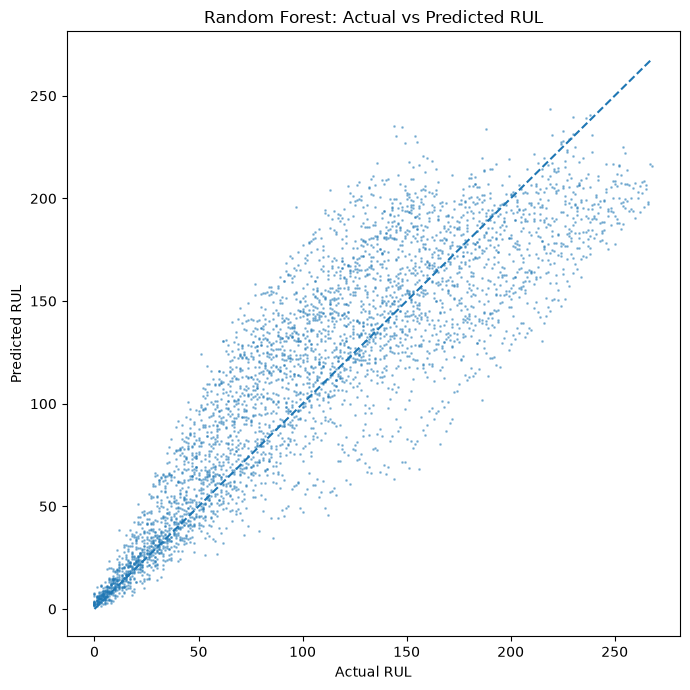

In [50]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_val,
    rf_pred,
    alpha=0.4,
    s=1
)

min_value = min(y_val.min(), rf_pred.min())
max_value = max(y_val.max(), rf_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Random Forest: Actual vs Predicted RUL")

plt.tight_layout()

plt.savefig(
    "../reports/FD001/figures/Random_Forest_Actual_vs_Predicted_RUL.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


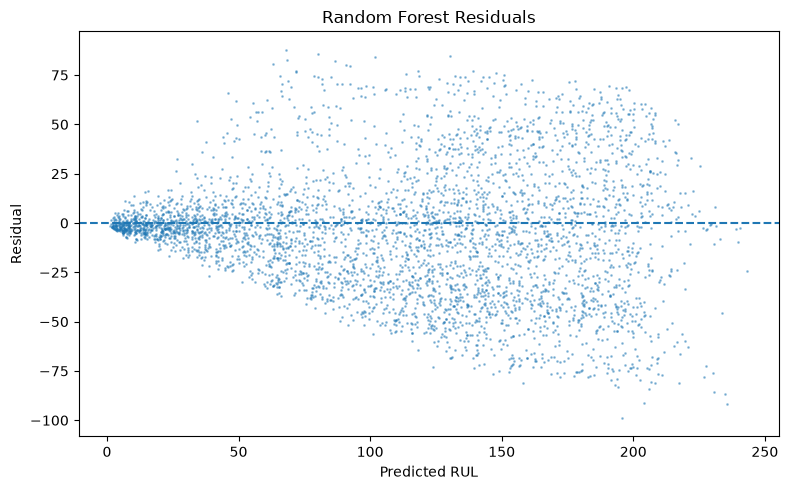

In [51]:
rf_residuals = y_val - rf_pred

plt.figure(figsize=(8, 5))

plt.scatter(
    rf_pred,
    rf_residuals,
    alpha=0.4,
    s=1
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted RUL")
plt.ylabel("Residual")
plt.title("Random Forest Residuals")

plt.tight_layout()

plt.savefig(
    "../reports/FD001/figures/Random_Forest_Residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
rf_results = pd.DataFrame({
    "model": ["Random Forest"],
    "MAE": [rf_mae],
    "RMSE": [rf_rmse],
    "R2": [rf_r2]
})

display(rf_results)

,model,MAE,RMSE,R2
0,Random Forest,23.938742,31.606191,0.768234


In [53]:
all_baseline_results = pd.concat(
    [all_baseline_results, rf_results],
    ignore_index=True
)

display(all_baseline_results)

all_baseline_results.to_csv(
    "../reports/FD001/baseline_results.csv",
    index=False
)

,model,MAE,RMSE,R2
0,Linear Regression,25.155168,31.655955,0.767504
1,Random Forest,23.938742,31.606191,0.768234


,feature,importance
0,cycle,0.535671
10,sensor_11,0.141243
9,sensor_9,0.045612
5,sensor_4,0.032715
13,sensor_14,0.030027
11,sensor_12,0.028131
7,sensor_7,0.023827
14,sensor_15,0.023116
17,sensor_21,0.021129
4,sensor_3,0.020045


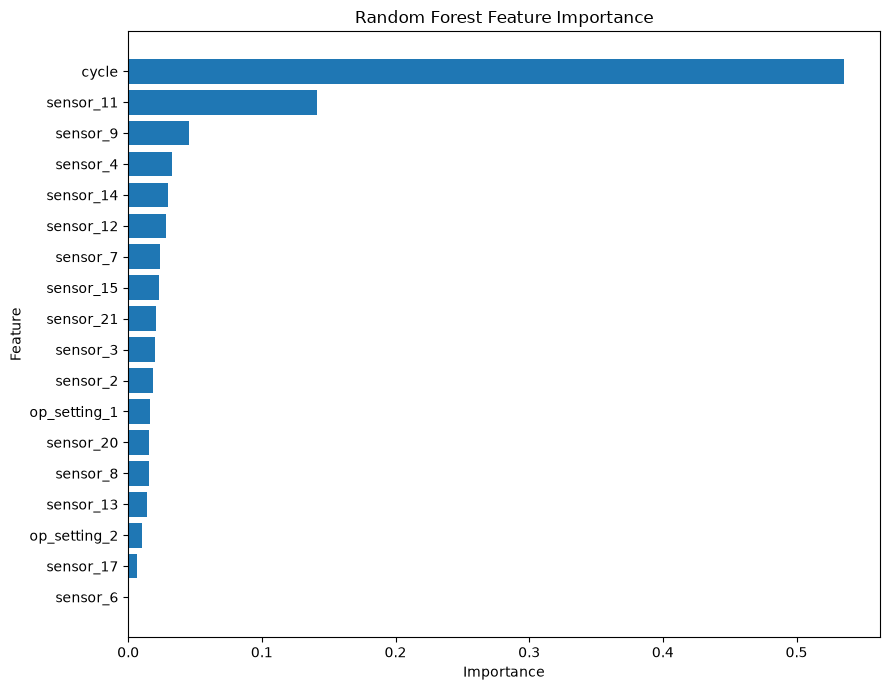

In [60]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

display(feature_importance)

plt.figure(figsize=(9, 7))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.savefig(
    "../reports/FD001/figures/Random_Forest_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Training XGBoost

In [54]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_val)

xgb_mae = mean_absolute_error(y_val, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_pred))
xgb_r2 = r2_score(y_val, xgb_pred)

print("XGBoost Results")
print("MAE :", round(xgb_mae, 3))
print("RMSE:", round(xgb_rmse, 3))
print("R²  :", round(xgb_r2, 3))

XGBoost Results
MAE : 23.678
RMSE: 31.189
R²  : 0.774


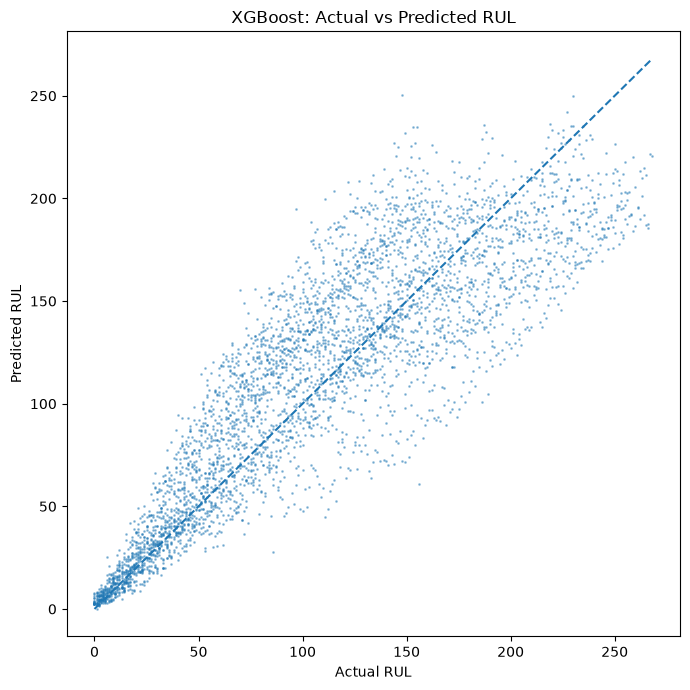

In [55]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_val,
    xgb_pred,
    alpha=0.4,
    s=1
)

min_value = min(y_val.min(), xgb_pred.min())
max_value = max(y_val.max(), xgb_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("XGBoost: Actual vs Predicted RUL")

plt.tight_layout()

plt.savefig(
    "../reports/FD001/figures/XGBoost_Actual_vs_Predicted_RUL.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


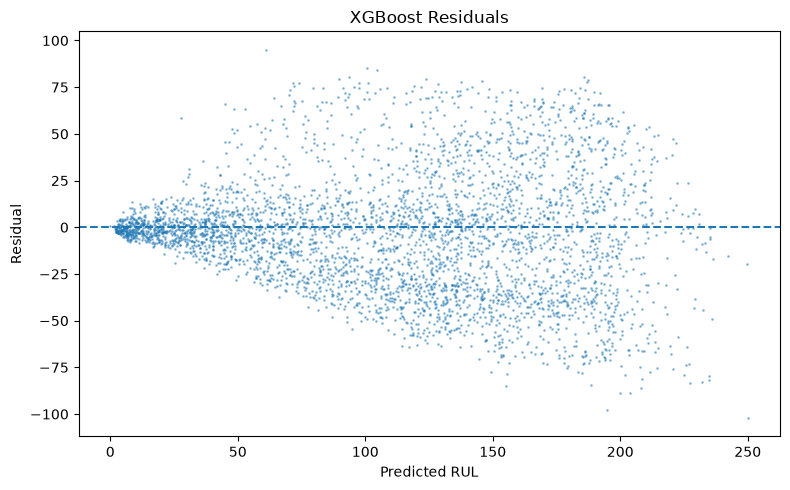

In [56]:
xgb_residuals = y_val - xgb_pred

plt.figure(figsize=(8, 5))

plt.scatter(
    xgb_pred,
    xgb_residuals,
    alpha=0.4,
    s=1
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted RUL")
plt.ylabel("Residual")
plt.title("XGBoost Residuals")

plt.tight_layout()

plt.savefig(
    "../reports/FD001/figures/XGBoost_Residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
xgb_results = pd.DataFrame({
    "model": ["XGBoost"],
    "MAE": [xgb_mae],
    "RMSE": [xgb_rmse],
    "R2": [xgb_r2]
})

display(xgb_results)

,model,MAE,RMSE,R2
0,XGBoost,23.678049,31.189005,0.774312


In [58]:
all_baseline_results = pd.concat(
    [all_baseline_results, xgb_results],
    ignore_index=True
)

display(all_baseline_results)

all_baseline_results.to_csv(
    "../reports/FD001/baseline_results.csv",
    index=False
)

print("Saved baseline results.")

,model,MAE,RMSE,R2
0,Linear Regression,25.155168,31.655955,0.767504
1,Random Forest,23.938742,31.606191,0.768234
2,XGBoost,23.678049,31.189005,0.774312


Saved baseline results.


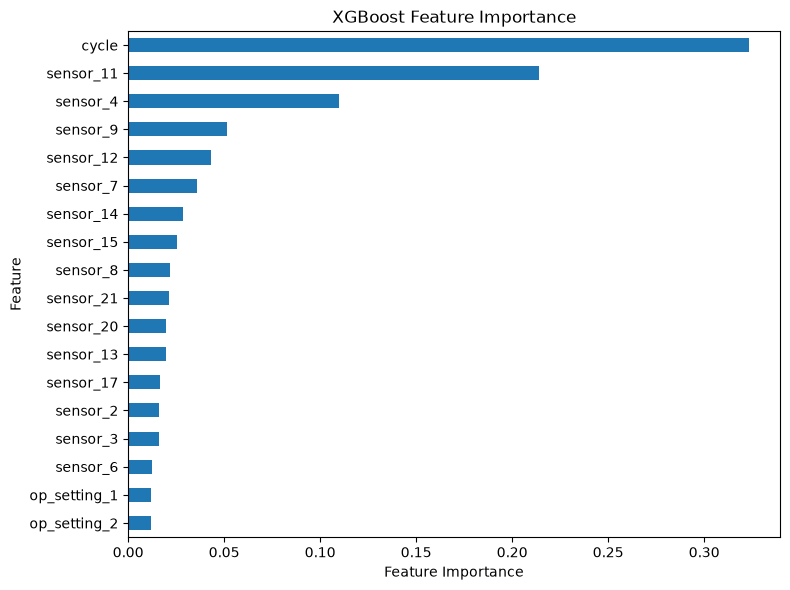

In [61]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))

xgb_importance.plot(kind="barh")

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.tight_layout()

plt.savefig(
    "../reports/FD001/figures/XGBoost_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()